In [147]:
import numpy as np
import pandas as pd
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib
from matplotlib import pyplot as plt
matplotlib.rcParams['font.sans-serif'] = ['DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False

np.random.seed(42)
torch.manual_seed(42)
file_path = '../datasets/housingPrice/data.xls'
df = pd.read_csv(file_path)
df = df.drop(columns=['date', 'street', 'city', 'statezip', 'country'])
print(df.shape)
X = df.drop(columns=['price']).values
y = df['price'].values.reshape(-1, 1)


(4600, 13)


In [148]:
import torch.nn as nn
import torch.nn.functional as F

class Net(nn.Module):
    def __init__(self, input_dim, drop_out_rate=0.3):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(drop_out_rate),

            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(drop_out_rate),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(drop_out_rate),

            nn.Linear(32, 1)

        )
        #self._initialize_weights()
        
    def forward(self, x):
        return self.network(x)


In [149]:
learning_rate = 0.0005
drop_rate = 0.1
batch_size = 64
num_epoches = 50

momentum = 0.5

In [150]:
from torch.utils.data import DataLoader, TensorDataset
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_val.shape)
X_train_scaled = scaler_x.fit_transform(X_train)
X_val_scaled = scaler_x.transform(X_val)
y_train_scaled = scaler_y.fit_transform(y_train)
y_val_scaled = scaler_y.transform(y_val)
train_dataset = TensorDataset(
    torch.tensor(X_train_scaled, dtype=torch.float32),
    torch.tensor(y_train_scaled, dtype=torch.float32)
)
val_dataset = TensorDataset(
    torch.tensor(X_val_scaled, dtype=torch.float32),
    torch.tensor(y_val_scaled, dtype=torch.float32)
)
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
eval_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)


(3680, 12) (920, 12)


In [151]:
model = Net(X_train.shape[1], drop_rate)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)


Net(
  (network): Sequential(
    (0): Linear(in_features=12, out_features=128, bias=True)
    (1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.1, inplace=False)
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.1, inplace=False)
    (8): Linear(in_features=64, out_features=32, bias=True)
    (9): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): Dropout(p=0.1, inplace=False)
    (12): Linear(in_features=32, out_features=1, bias=True)
  )
)

In [152]:
from torch import optim
optimizer = optim.AdamW(
    model.parameters(),
    lr=learning_rate,
    weight_decay=1e-4
)

criterion = nn.HuberLoss(delta=1.0)
schedular = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=10,
    verbose=True
)
history = {'train_loss':[], 'val_loss':[]}

/home/repiece/miniconda3/envs/ai-base/lib/python3.11/site-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


In [153]:
train_losses = []
eval_losses = []

for epoch in range(num_epoches):
    train_loss = 0
    eval_loss = 0

    model.train()

    for X_batch, y_batch in train_dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
        optimizer.step()
        train_loss+=loss.item()
    avg_train_loss = train_loss / len(train_dataloader) if len(train_dataloader) > 0 else 0
    train_losses.append(avg_train_loss)
    schedular.step(avg_eval_loss)
    model.eval()
    model.network.eval()
    with torch.no_grad():
        for X_batch, y_batch in eval_dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            eval_loss += loss.item()
    avg_eval_loss = eval_loss / len(eval_dataloader) if len(eval_dataloader) > 0 else 0
    eval_losses.append(avg_eval_loss)
    print(f'epoch{epoch:03d}/{num_epoches-1}, train loss:{train_loss}, eval loss:{eval_loss}')
    



epoch000/49, train loss:12.801293931901455, eval loss:5.949398770928383
epoch001/49, train loss:10.654325798153877, eval loss:5.912939913570881
epoch002/49, train loss:10.536523632705212, eval loss:5.841561987996101
epoch003/49, train loss:10.332902610301971, eval loss:5.876784510910511
epoch004/49, train loss:10.290345445275307, eval loss:5.843174807727337
epoch005/49, train loss:10.331563785672188, eval loss:5.855027765035629
epoch006/49, train loss:10.002751670777798, eval loss:5.8075979351997375
epoch007/49, train loss:9.742283195257187, eval loss:5.816699899733067
epoch008/49, train loss:9.98631077259779, eval loss:5.8091378808021545
epoch009/49, train loss:9.752221129834652, eval loss:5.831692449748516
epoch010/49, train loss:9.70067772269249, eval loss:5.799189537763596
epoch011/49, train loss:9.835480891168118, eval loss:5.80790713429451
epoch012/49, train loss:9.662498965859413, eval loss:5.784556962549686
epoch013/49, train loss:9.23585369437933, eval loss:5.776909343898296
e

[0.22071196434312854, 0.1836952723819634, 0.18166420056388297, 0.17815349328106847, 0.17741974905647082, 0.17813041009779634, 0.17246123570306549, 0.16797039991822735, 0.1721777719413412, 0.16814174361783882, 0.16725306418435326, 0.1695772567442779, 0.16659480975619678, 0.1592388567996436, 0.16333913327804928, 0.16162515393105045, 0.16355460034362201, 0.1639095253214754, 0.16104386143129448, 0.16315042612881497, 0.16628151271363784, 0.15862039104104042, 0.15964734502907457, 0.15634489059448242, 0.15631227143879595, 0.15894565692749515, 0.1610384606595697, 0.15942360242379122, 0.1595637982646967, 0.15967334858302412, 0.16088903592578296, 0.15990622405861987, 0.15407322128785067, 0.15422613148031564, 0.1556438884601511, 0.15263669719469958, 0.15309490391920352, 0.15822768699506234, 0.15534902569548836, 0.15566209562379738, 0.16063458678023568, 0.15456187147004852, 0.15276466361407576, 0.1506122918478374, 0.15624921165149788, 0.15571268827750764, 0.15342704373700866, 0.1543163262821477, 0

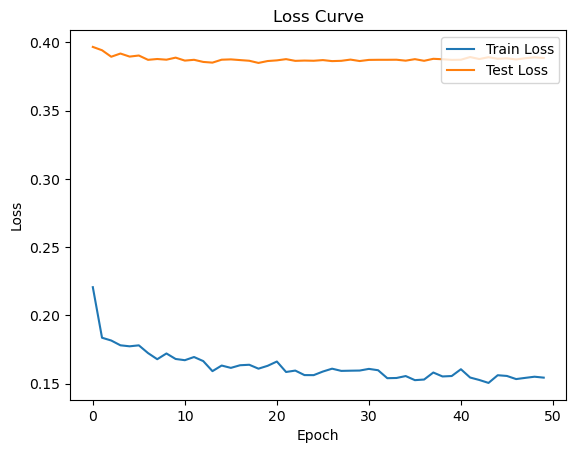

In [154]:
print(train_losses)
plt.title("Loss Curve")
plt.plot(np.arange(len(train_losses)), train_losses, label='Train Loss')
plt.plot(np.arange(len(eval_losses)), eval_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(['Train Loss', 'Test Loss'], loc='upper right')
plt.show()